In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("diabetes_risk.csv")
df.head()

,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


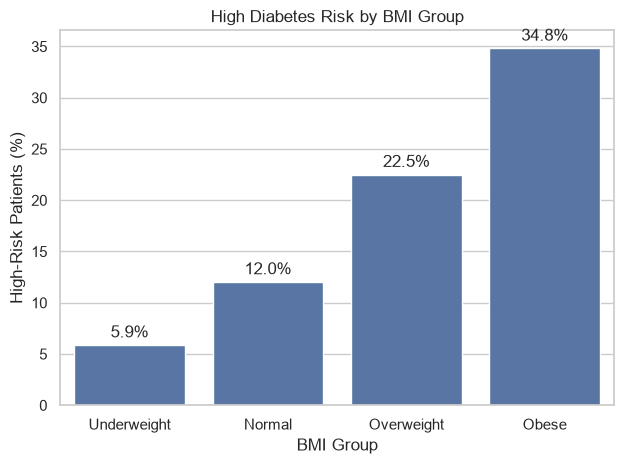

In [11]:
# Create BMI groups
df["bmi_group"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"]
)

# Calculate High-risk rate
risk_rate = (
    df.groupby("bmi_group", observed=True)["diabetes_risk"]
      .apply(lambda x: (x == "High").mean() * 100)
      .reset_index(name="high_risk_pct")
)

# Plot
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=risk_rate,
    x="bmi_group",
    y="high_risk_pct"
)

ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)

plt.title("High Diabetes Risk by BMI Group")
plt.xlabel("BMI Group")
plt.ylabel("High-Risk Patients (%)")
plt.tight_layout()
plt.show()